In [1]:
%load_ext autoreload  
%autoreload 2 

In [2]:
import pandas as pd
import gzip
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import savgol_filter

In [3]:
samples = {'samp26_t1':'cancer','samp26_t2':'cancer', 'samp26_t3':'cancer', 'samp58':'benign', 'samp82':'benign'}
color_dict = {'samp26_t1':'#588157','samp26_t2':'#588157', 'samp26_t3':'#588157', 'samp58':'grey', 'samp82':'grey'}

In [13]:
import matplotlib.pyplot as plt

def plot_fcc(df, tf_col="TF"):
    """
    Plot FCC profiles for each TF group:
    - mean_FCC (ghost line)
    - smoothed_FCC (color 1)
    - normalized_FCC (color 2)
    """

    # enforce sorted positions per TF, avoids zig-zagging lines
    df = df.sort_values(["TF", "position"])

    for tf, sub in df.groupby(tf_col):
        fig, ax = plt.subplots(figsize=(10, 5))

        # almost transparent mean FCC
        ax.plot(
            sub["position"],
            sub["mean_FCC"],
            alpha=0.15,
            linewidth=2,
            label="mean_FCC"
        )

        # smoothed FCC (color 1)
        ax.plot(
            sub["position"],
            sub["smoothed_FCC"],
            linewidth=2,
            label="smoothed_FCC"
        )

        # normalized FCC (color 2)
        ax.plot(
            sub["position"],
            sub["normalized_FCC"],
            linewidth=2,
            label="normalized_FCC"
        )

        ax.set_title(f"FCC Profile — {tf}")
        ax.set_xlabel("Position")
        ax.set_ylabel("FCC signal")
        ax.legend()
        ax.grid(alpha=0.2)

        plt.show()


# CDX2

In [15]:
samp26_t1 = pd.read_csv('../data/samples/SeCT-26_t1/griffin_profiling/composite/CDX2_FCC_profile.tsv.gz', delimiter='\t')
samp26_t2 = pd.read_csv('../data/samples/SeCT-26_t2/griffin_profiling/composite/CDX2_FCC_profile.tsv.gz', delimiter='\t')
samp26_t3 = pd.read_csv('../data/samples/SeCT-26_t3/griffin_profiling/composite/CDX2_FCC_profile.tsv.gz', delimiter='\t')

samp58 = pd.read_csv('../data/samples/SeCT-58/griffin_profiling/composite/CDX2_FCC_profile.tsv.gz', delimiter='\t')
samp82 = pd.read_csv('../data/samples/SeCT-82/griffin_profiling/composite/CDX2_FCC_profile.tsv.gz', delimiter='\t')

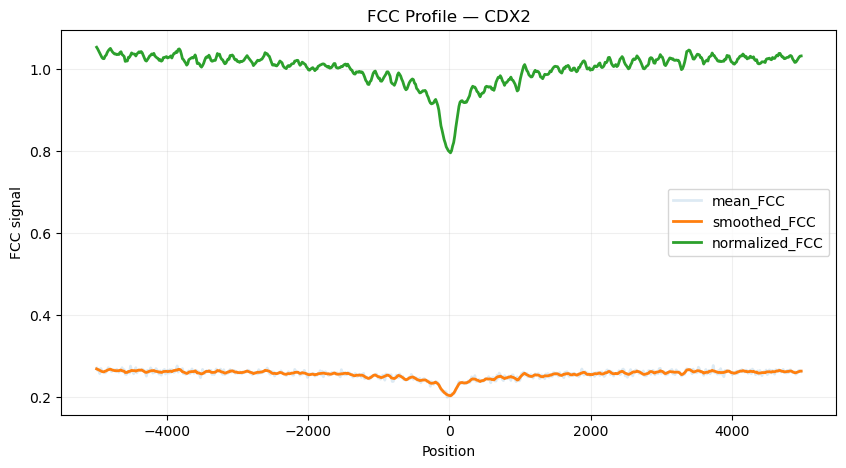

In [20]:
plot_fcc(samp26_t2)

# Comparison between groups

Plotting CDX2...


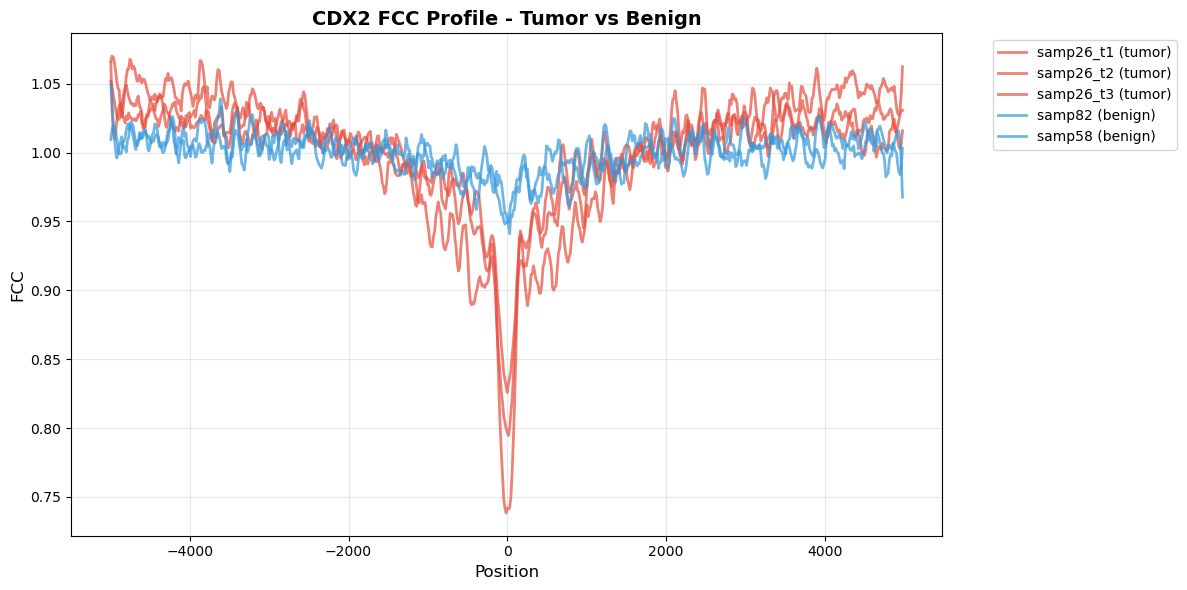

Plotting FOXA1...


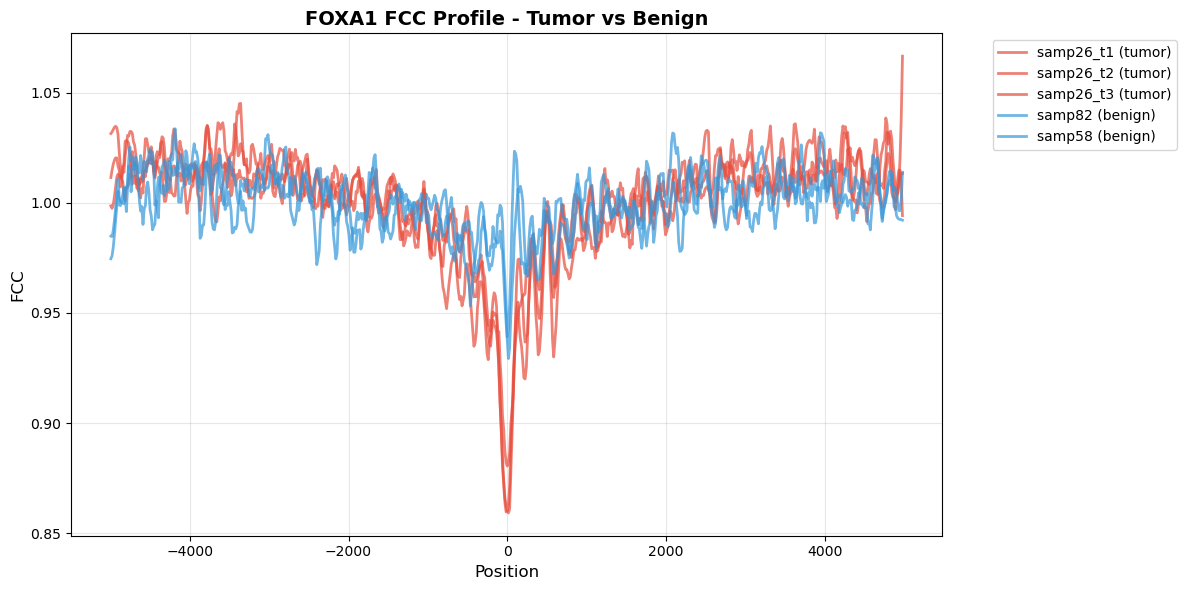

Plotting HNF4A...


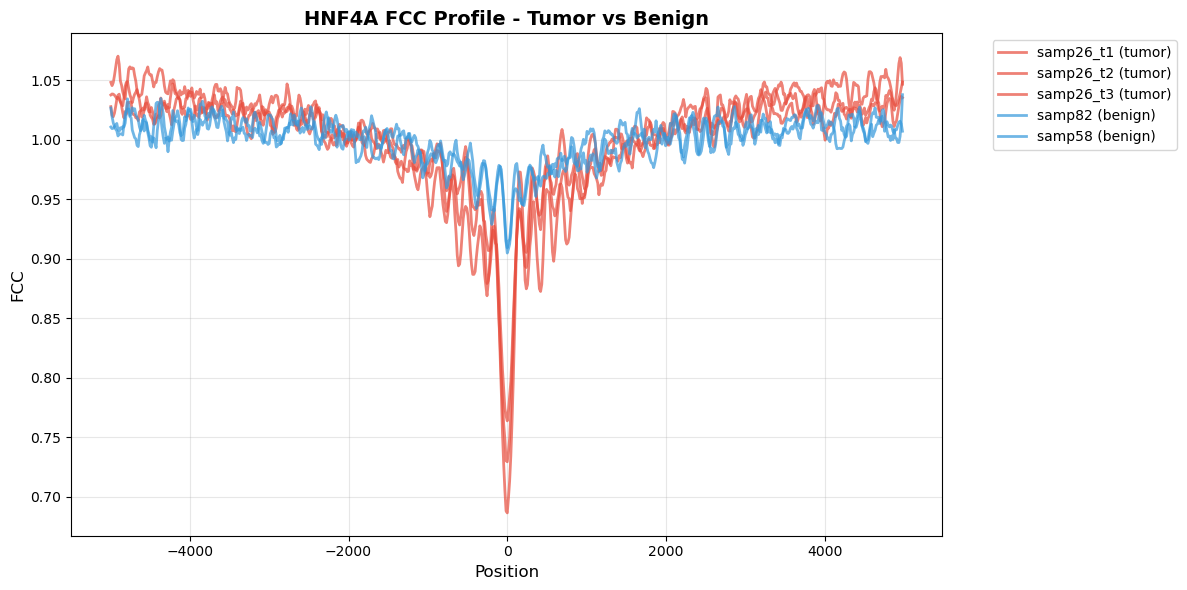

Plotting GATA6...


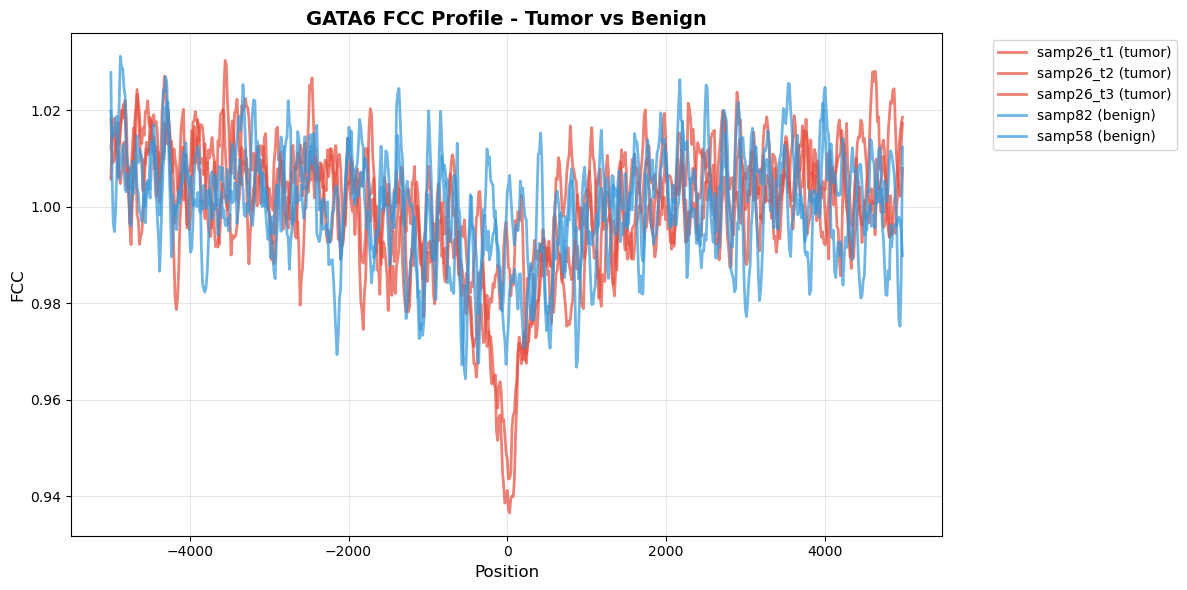

Plotting CTCF...


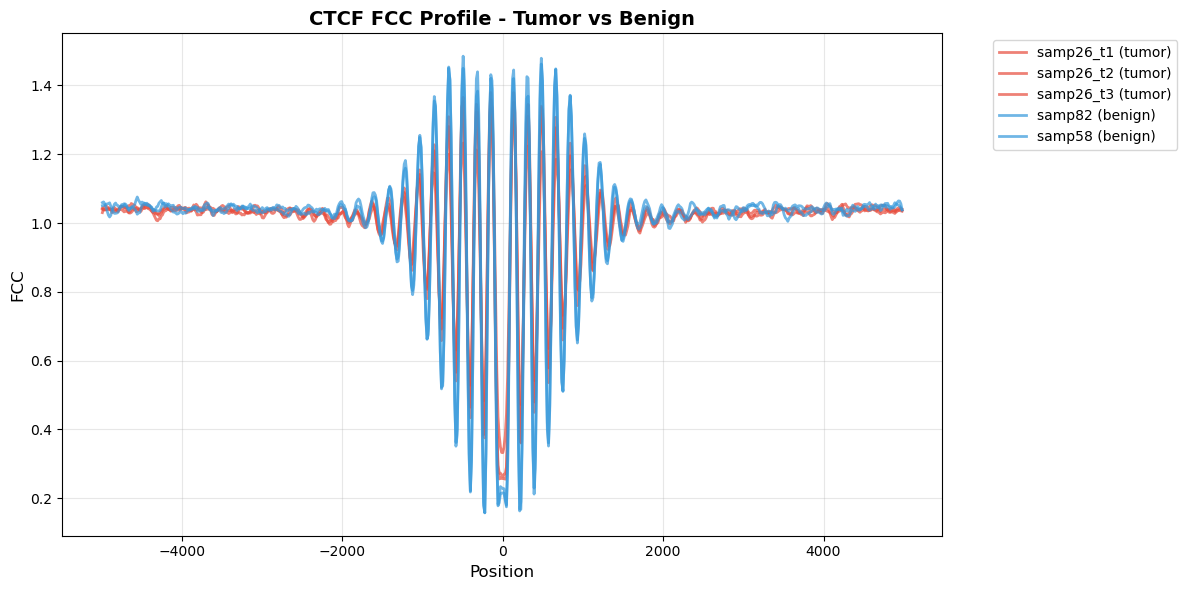

Plotting DLX2...


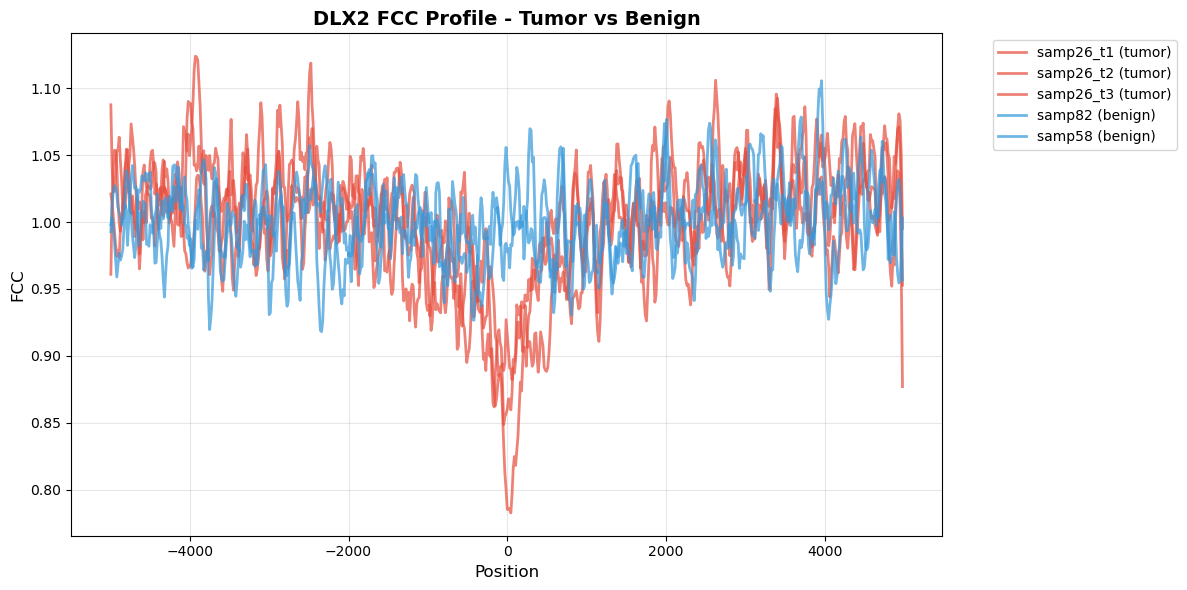

Plotting GRHL2...


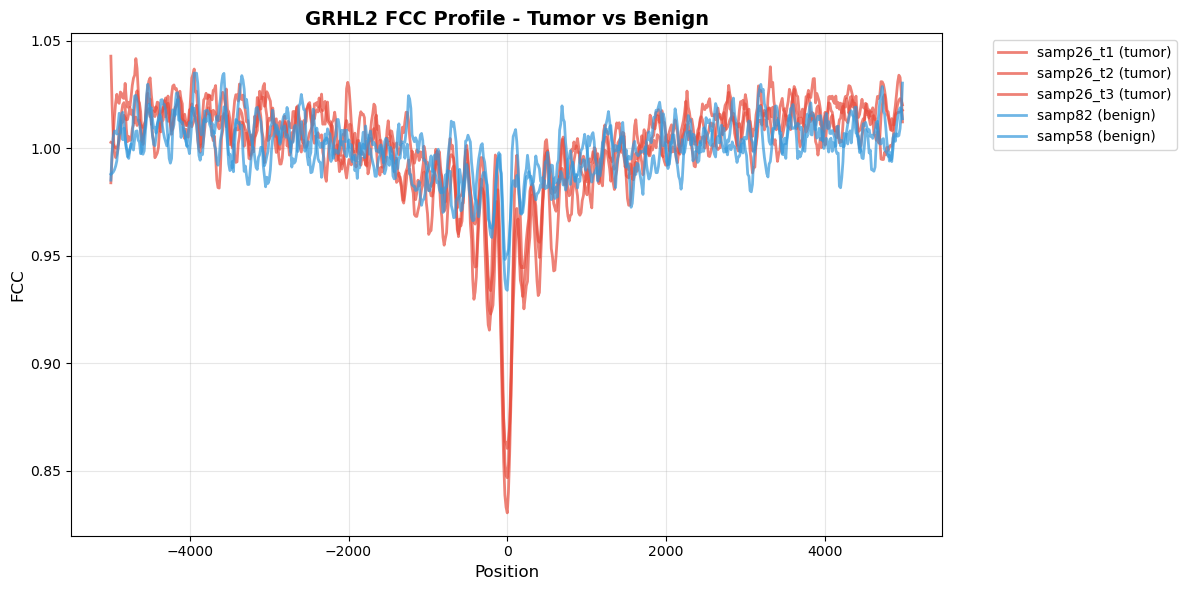

Plotting HNF1A...


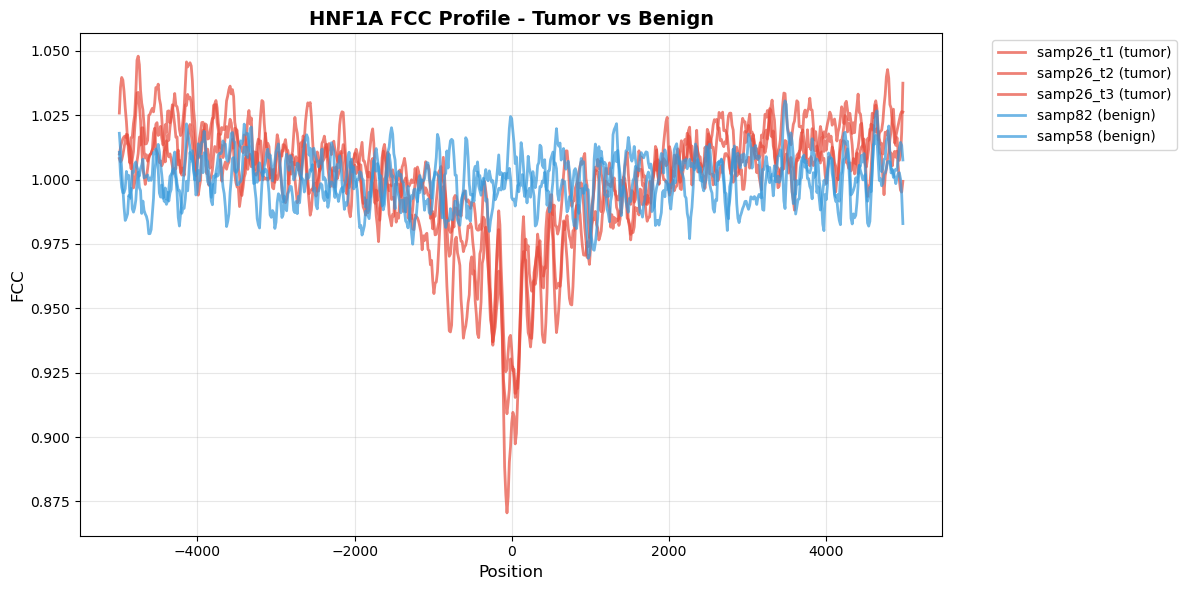

Plotting HNF4G...


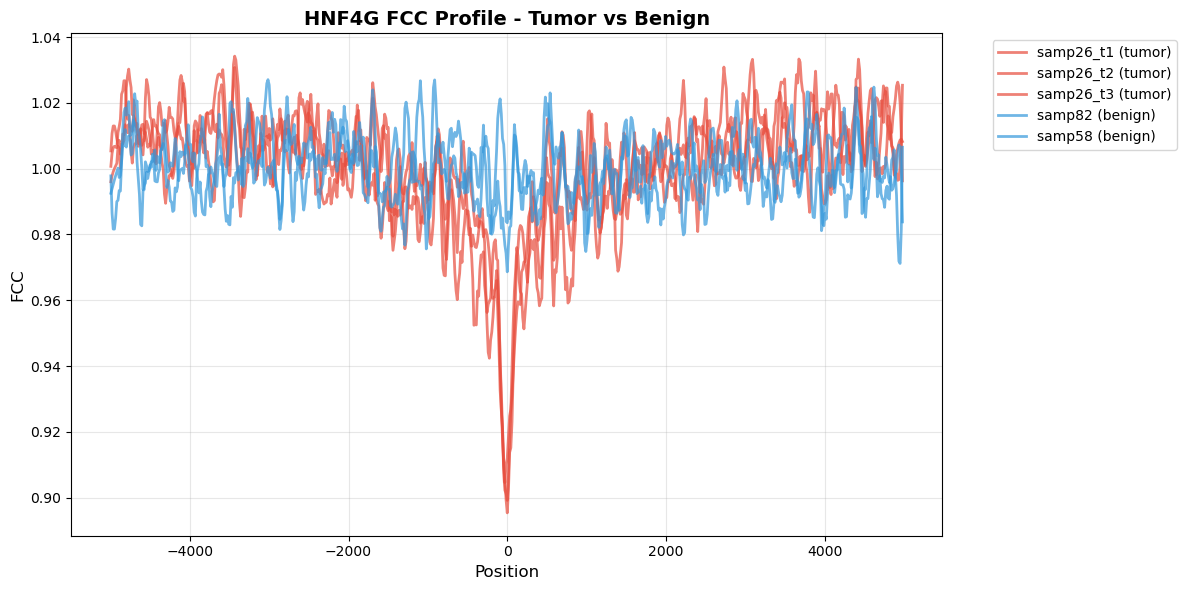

Plotting HOXA9...


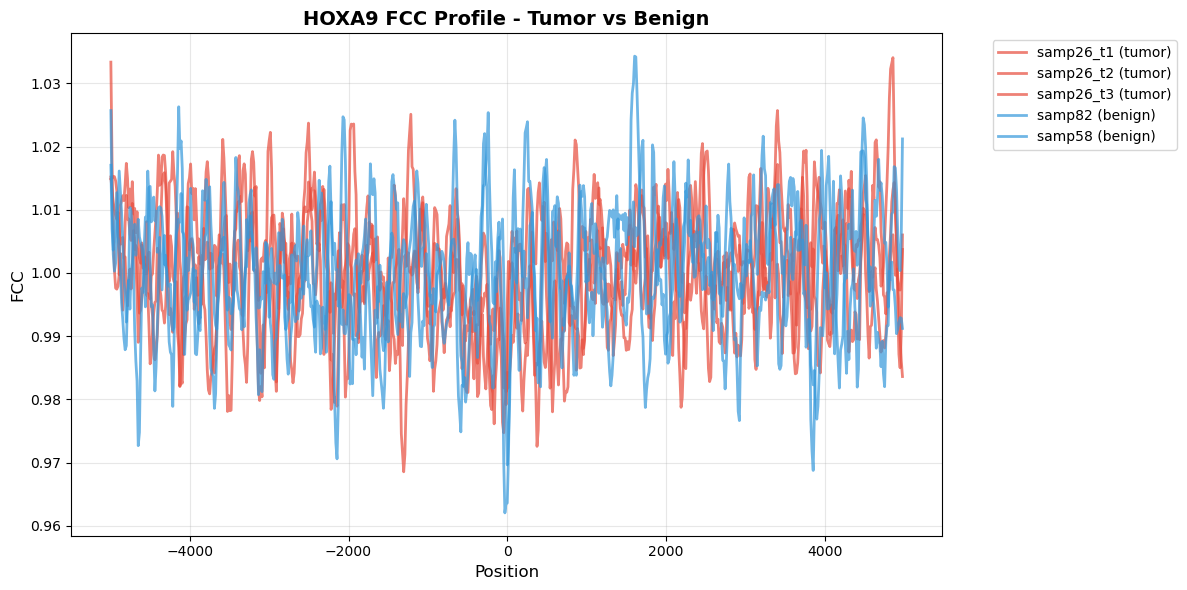

Plotting HOXB13...


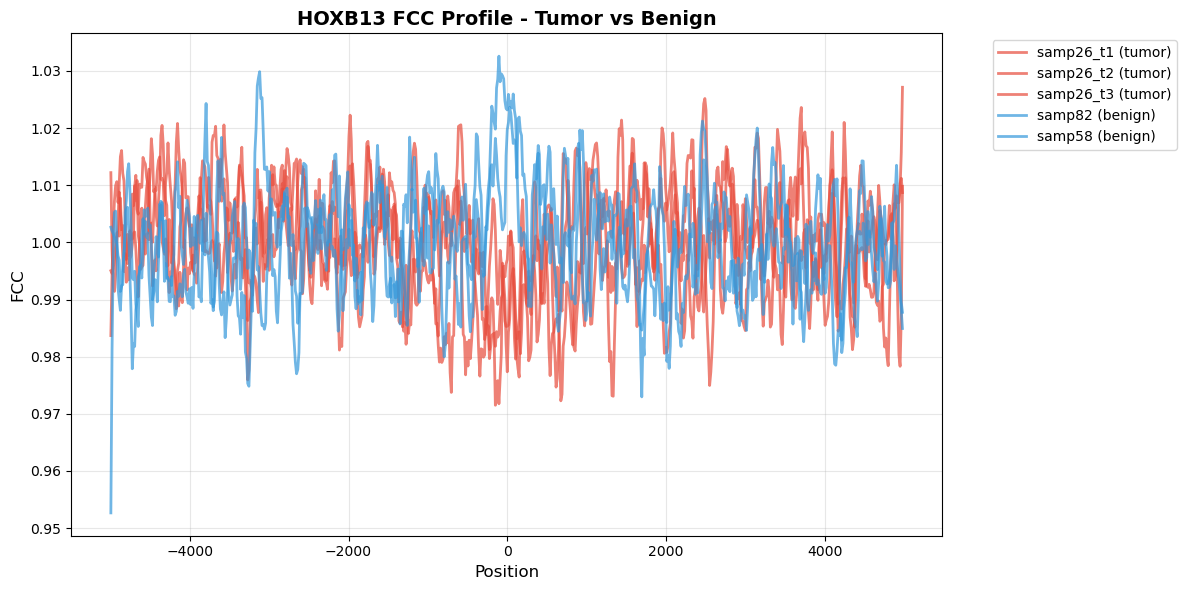

Plotting LYL1...


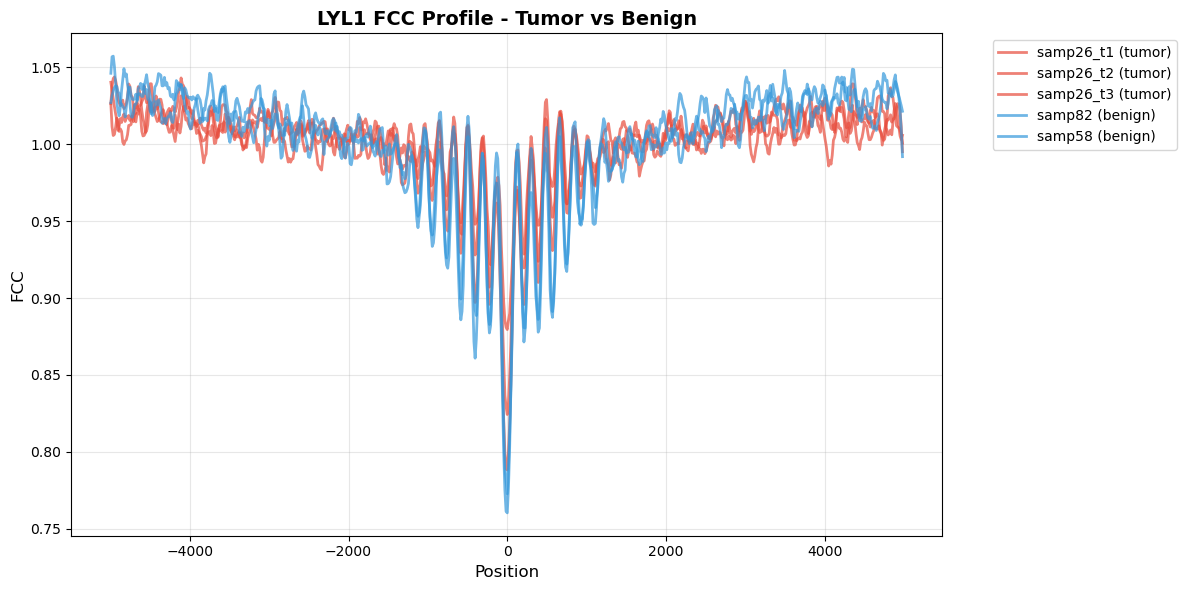

Plotting MYC...


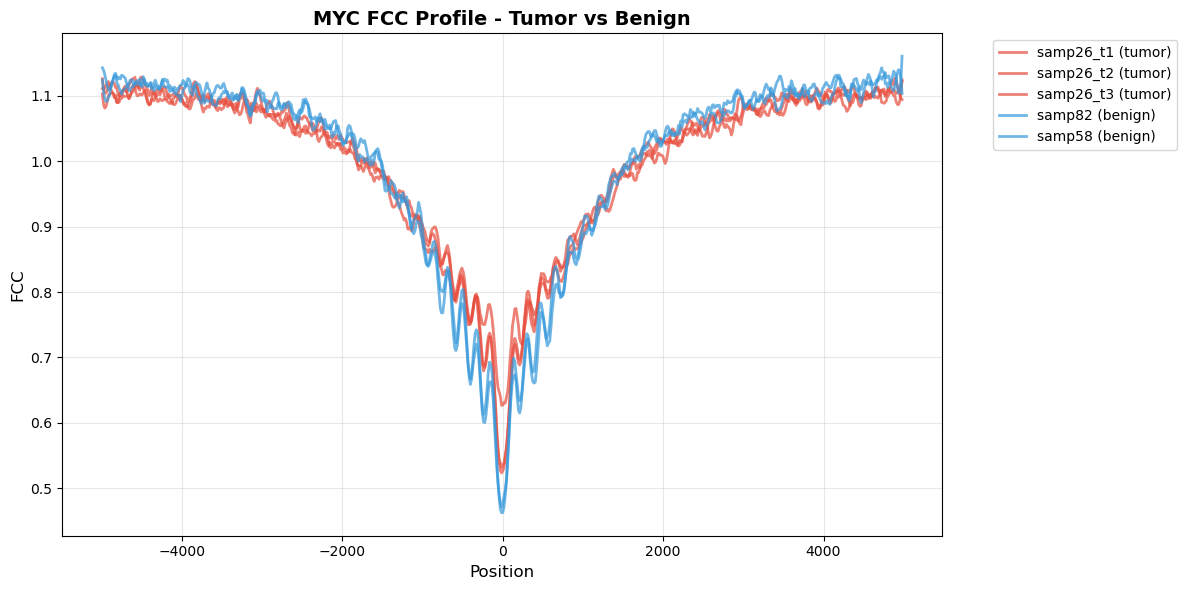

Plotting SOX4...


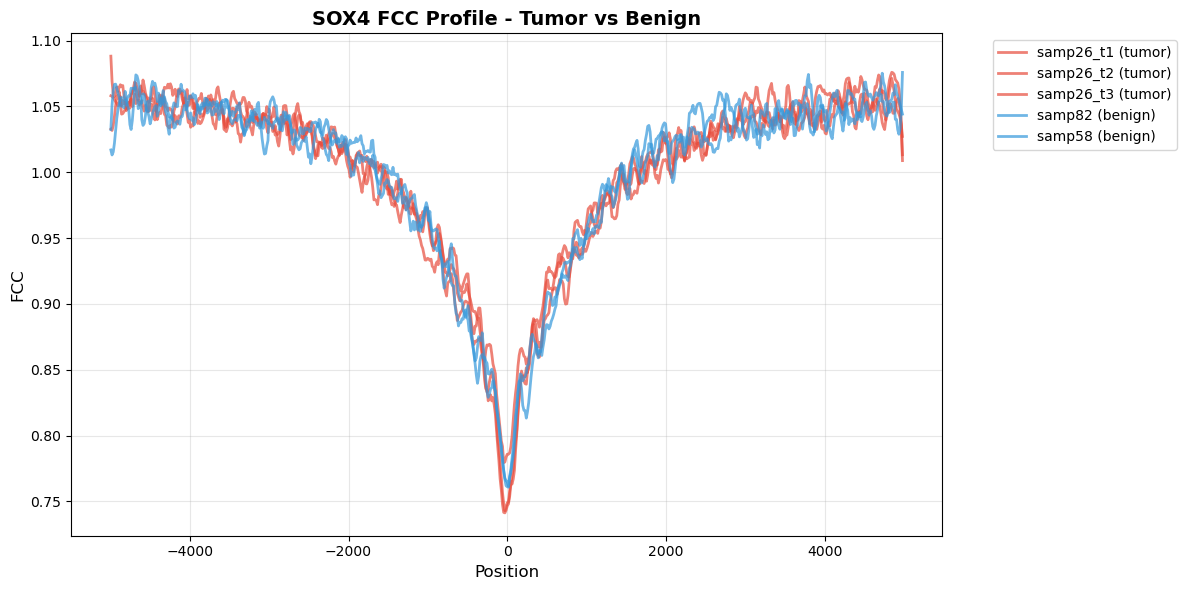

Plotting SOX9...


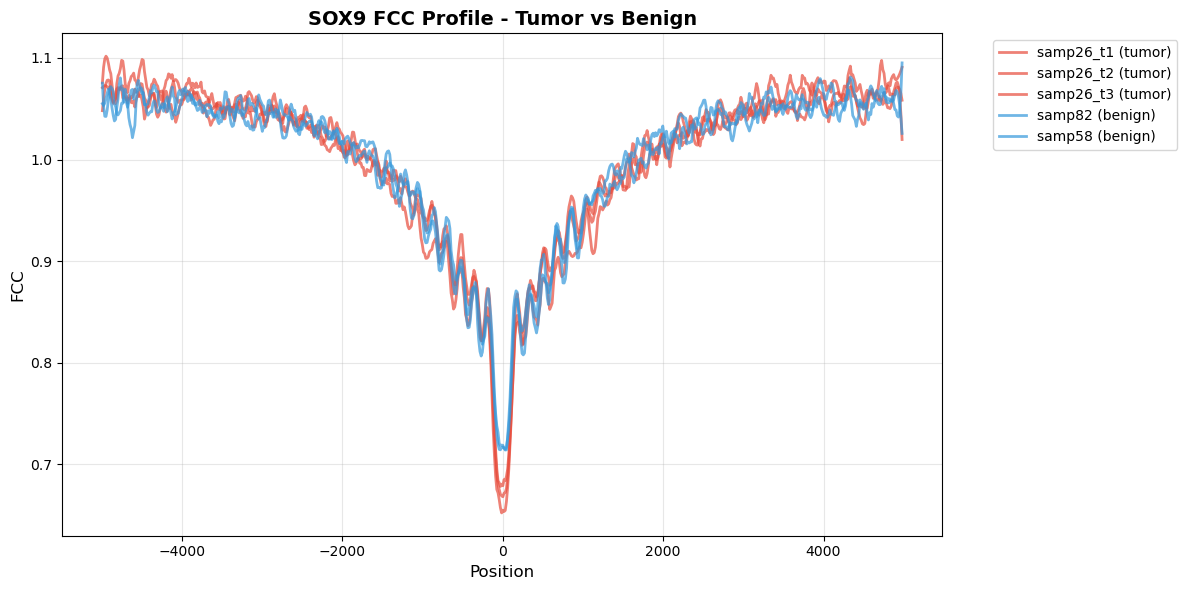

Plotting SPIB...


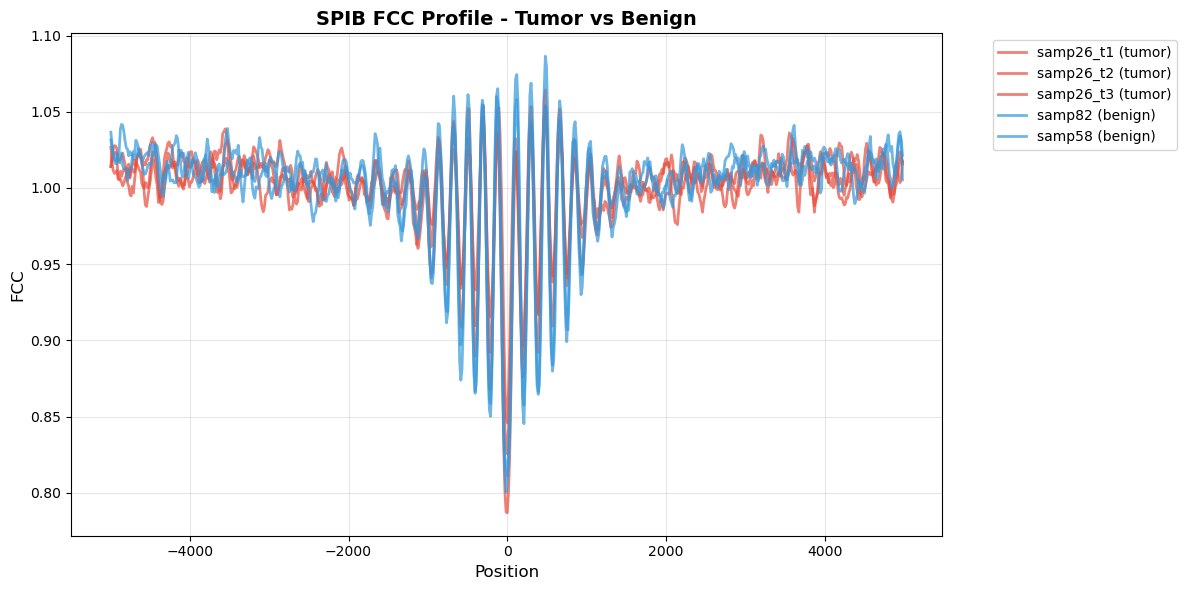

Plotting TAL1...


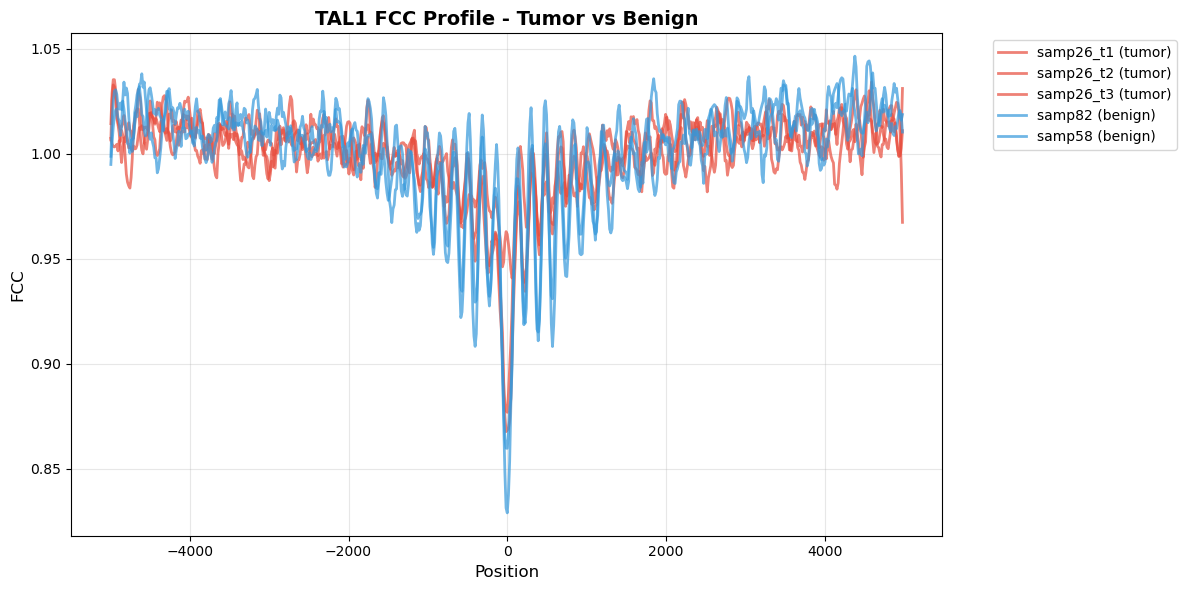

Plotting TBX21...


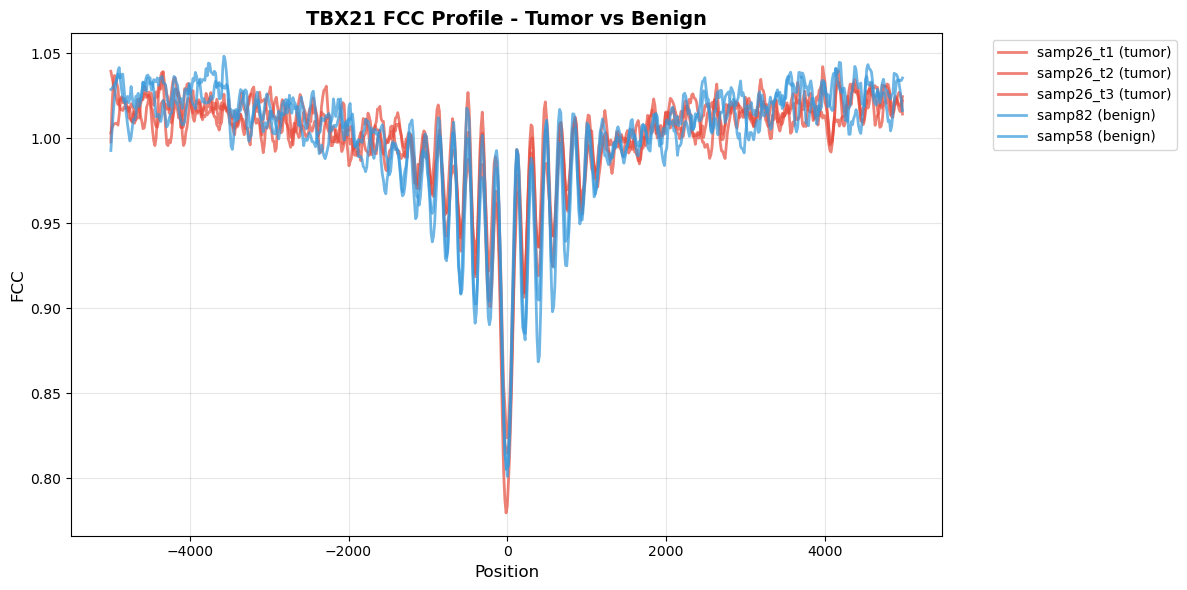

Plotting TCF7L2...


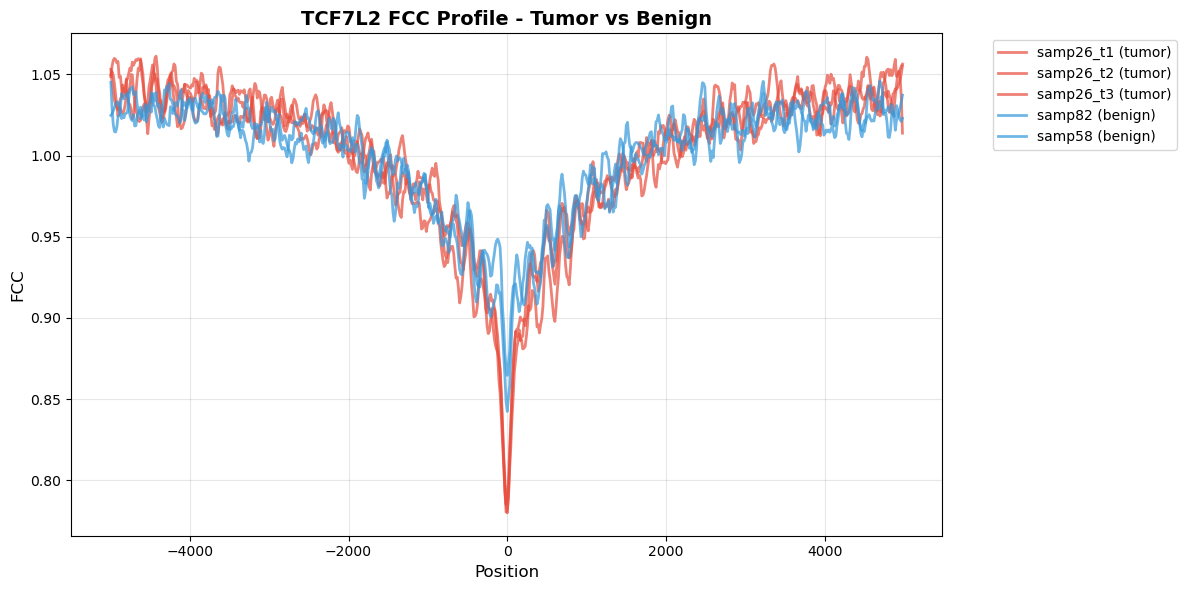

In [4]:
def plot_comparison(tf_name, samples_dict, group_dict, base_path):
    """
    Plot all samples for a given TF on the same plot, colored by group
    
    Parameters:
    - tf_name: Name of the transcription factor (e.g., 'CDX2')
    - samples_dict: Dictionary mapping sample names to their paths
    - group_dict: Dictionary mapping sample names to groups ('tumor' or 'benign')
    - base_path: Base path to the data directory
    """
    plt.figure(figsize=(12, 6))
    
    # Define colors for groups
    group_colors = {
        'tumor': '#E74C3C',      # Red
        'benign': '#3498DB'      # Blue
    }
    
    for sample_name, sample_id in samples_dict.items():
        # Load the data
        file_path = f"{base_path}/{sample_id}/griffin_profiling/composite/{tf_name}_FCC_profile.tsv.gz"
        df = pd.read_csv(file_path, sep="\t", compression="gzip")
        
        # Get group and color
        group = group_dict[sample_name]
        color = group_colors[group]
        
        # Plot the profile
        # Adjust these column names based on your actual data structure
        plt.plot(df['position'], df['normalized_FCC'], 
                label=f'{sample_name} ({group})', 
                color=color, 
                alpha=0.7,
                linewidth=2)
    
    plt.xlabel('Position', fontsize=12)
    plt.ylabel('FCC', fontsize=12)
    plt.title(f'{tf_name} FCC Profile - Tumor vs Benign', fontsize=14, fontweight='bold')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{tf_name}_tumor_vs_benign.pdf', dpi=300, bbox_inches='tight')
    plt.show()

# Define your samples and their groups
base_path = "/cluster/work/medinfmk/cfDNA-SeCT/irene_tfp/data/samples"

samples_dict = {
    'samp26_t1': 'SeCT-26_t1',
    'samp26_t2': 'SeCT-26_t2',
    'samp26_t3': 'SeCT-26_t3',
    'samp82': 'SeCT-82',
    'samp58': 'SeCT-58',
}

group_dict = {
    'samp26_t1': 'tumor',
    'samp26_t2': 'tumor',
    'samp26_t3': 'tumor',
    'samp82': 'benign',
    'samp58': 'benign',
}

# List of TFs to analyze
tfs = ['CDX2', 'FOXA1', 'HNF4A', 'GATA6','CTCF','DLX2','GRHL2','HNF1A','HNF4G', 'HOXA9', 'HOXB13', 'LYL1', 'MYC','SOX4','SOX9','SPIB','TAL1','TBX21','TCF7L2']  # Add your TFs here

# Generate one plot per TF
for tf in tfs:
    print(f"Plotting {tf}...")
    plot_comparison(tf, samples_dict, group_dict, base_path)

# Comparison with mean

In [5]:
def plot_fcc_comparison(tf_name, samples_dict, group_dict, base_path, 
                        figsize=(12, 6), show_mean=True):
    """
    Plot normalized FCC profiles for all samples on the same plot, colored by group.
    
    Parameters:
    -----------
    tf_name : str
        Name of the transcription factor (e.g., 'CDX2')
    samples_dict : dict
        Dictionary mapping sample names to their sample IDs
    group_dict : dict
        Dictionary mapping sample names to groups ('tumor' or 'benign')
    base_path : str
        Base path to the data directory
    figsize : tuple
        Figure size
    show_mean : bool
        If True, also plot the mean line for each group
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    group_colors = {'tumor': '#E74C3C', 'benign': '#3498DB'}
    group_data = {'tumor': [], 'benign': []}
    
    # Load and plot all samples
    for sample_name, sample_id in samples_dict.items():
        file_path = f"{base_path}/{sample_id}/griffin_profiling/composite/{tf_name}_FCC_profile.tsv.gz"
        df = pd.read_csv(file_path, sep="\t", compression="gzip")
    
        # ✅ keep only positions -1000 to +1000
        df = df[(df['position'] >= -1000) & (df['position'] <= 1000)]
    
        group = group_dict[sample_name]
        
        ax.plot(df['position'], df['normalized_FCC'], 
               color=group_colors[group], 
               alpha=0.4, 
               linewidth=1.5,
               label=f'{sample_name} ({group})' if not show_mean else None)
        
        group_data[group].append(df)
    
    # Plot mean lines for each group
    if show_mean:
        for group, dfs in group_data.items():
            positions = dfs[0]['position']
            mean_fcc = np.mean([df['normalized_FCC'].values for df in dfs], axis=0)
            std_fcc = np.std([df['normalized_FCC'].values for df in dfs], axis=0)
            
            ax.plot(positions, mean_fcc, 
                   color=group_colors[group], 
                   linewidth=3, 
                   label=f'{group.capitalize()} mean (n={len(dfs)})')
            
            ax.fill_between(positions, 
                            mean_fcc - std_fcc, 
                            mean_fcc + std_fcc, 
                            color=group_colors[group], 
                            alpha=0.15)
    
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='TF Summit', alpha=0.7)
    ax.set_xlabel('Distance from TF summit (bp)', fontsize=12)
    ax.set_ylabel('Normalized Fragment Center Coverage (FCC)', fontsize=12)
    ax.set_title(f'{tf_name} - Tumor vs Benign Comparison', fontsize=14, fontweight='bold')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    



######################################################################
# Processing CDX2
######################################################################


######################################################################
# Processing FOXA1
######################################################################


######################################################################
# Processing HNF4A
######################################################################


######################################################################
# Processing GATA6
######################################################################


######################################################################
# Processing CTCF
######################################################################


######################################################################
# Processing DLX2
######################################################################


########################

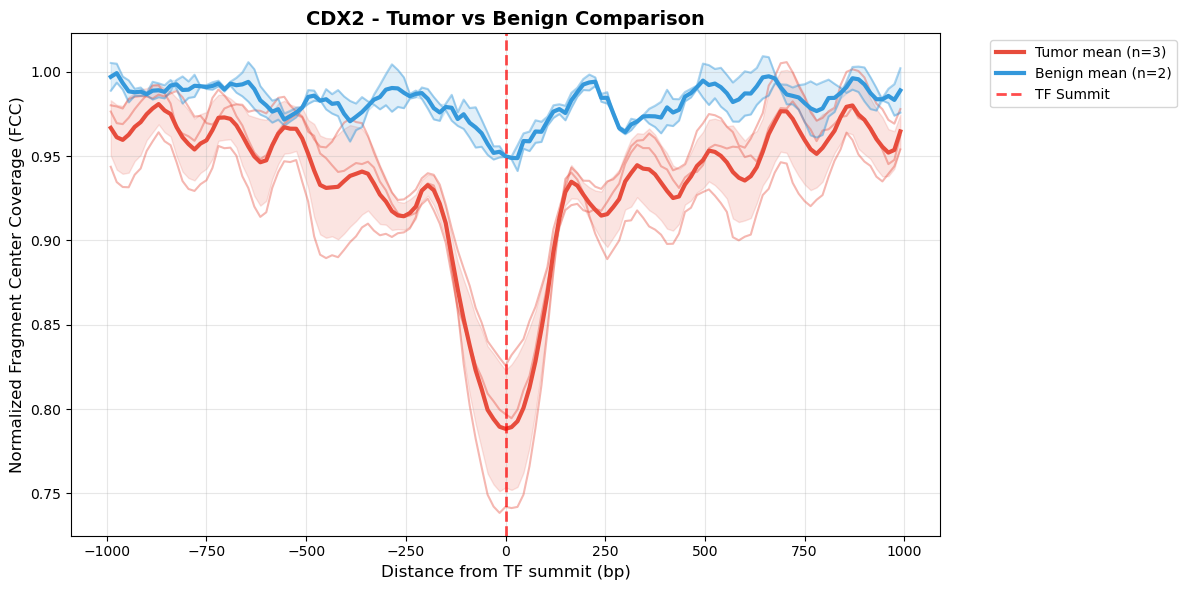

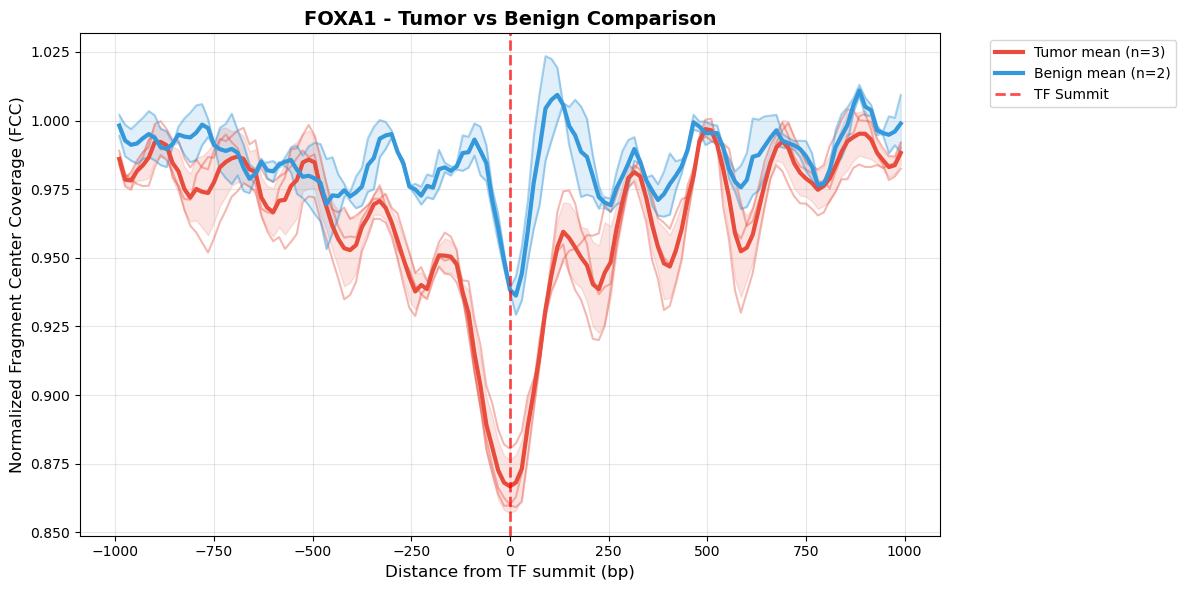

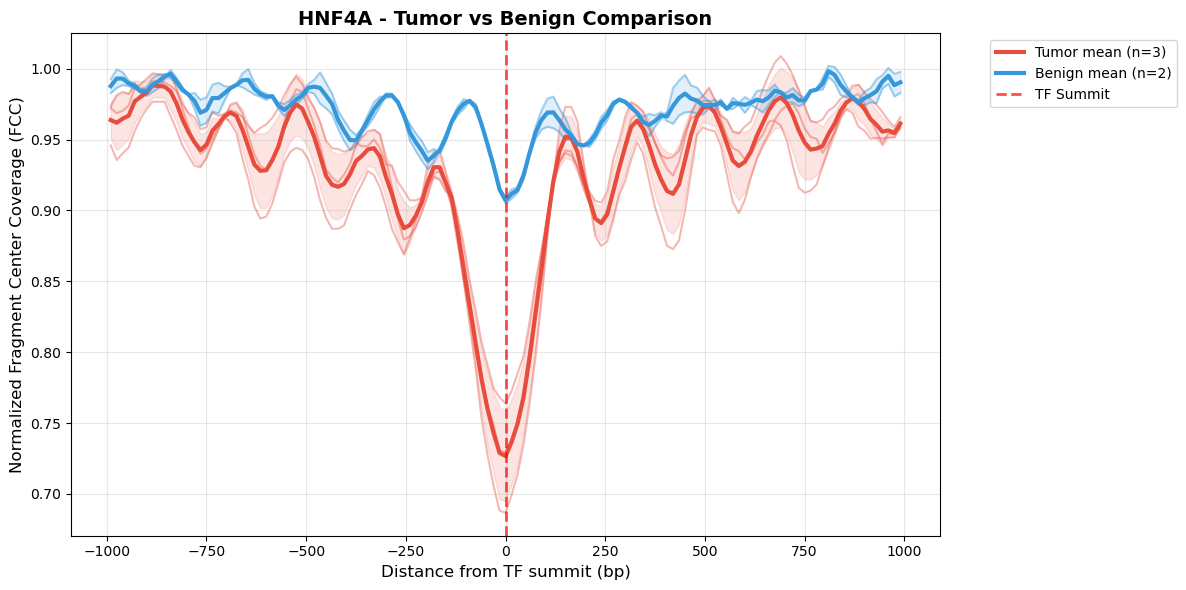

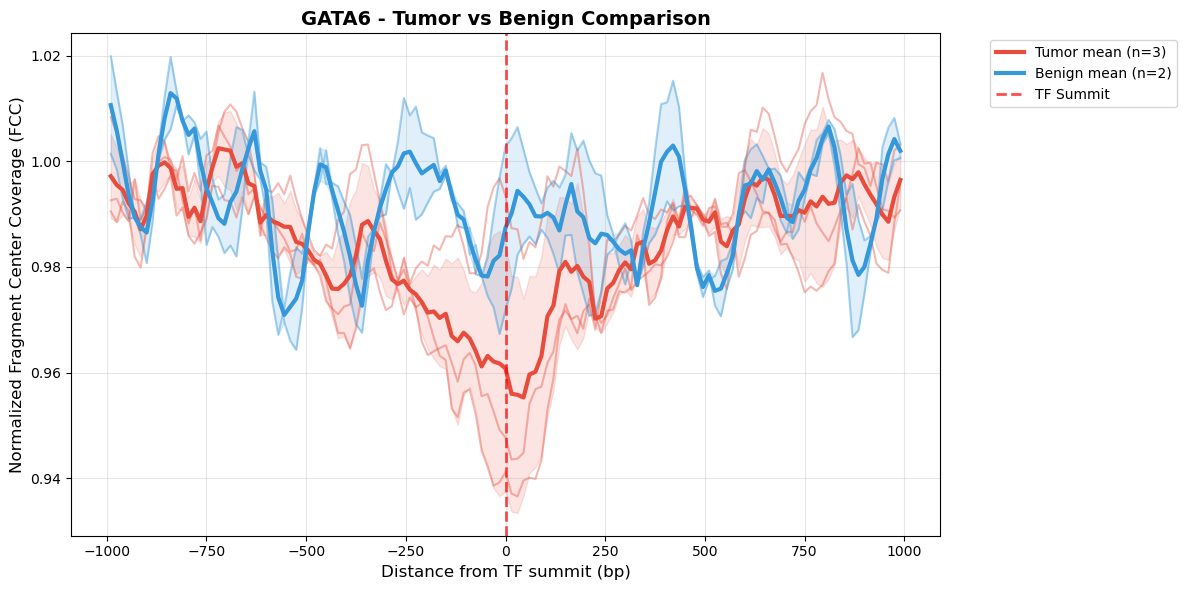

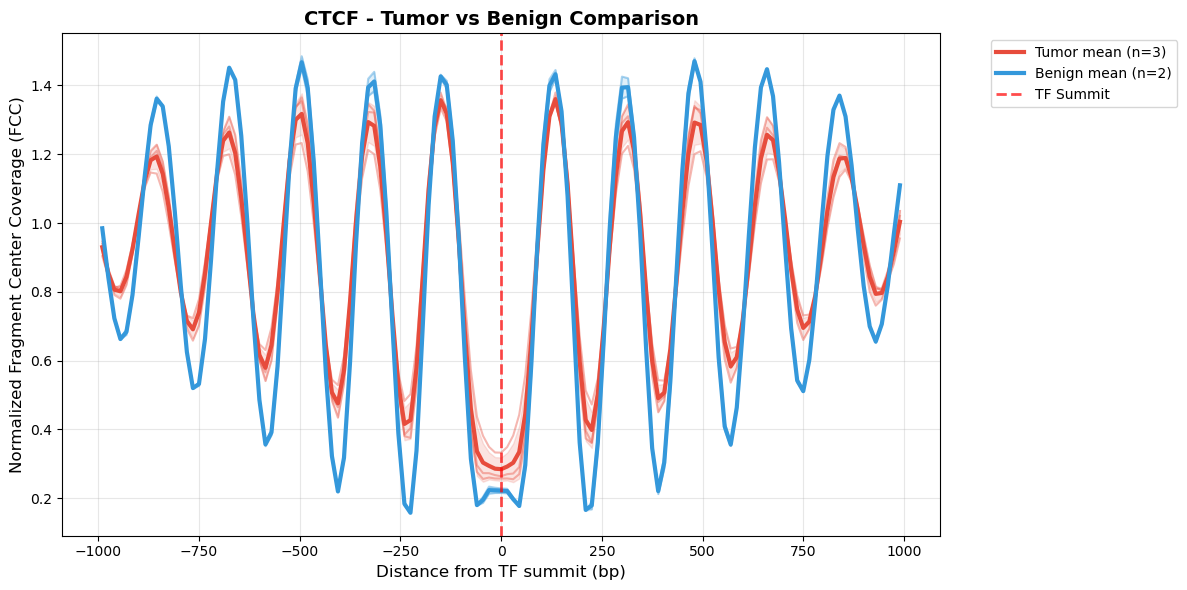

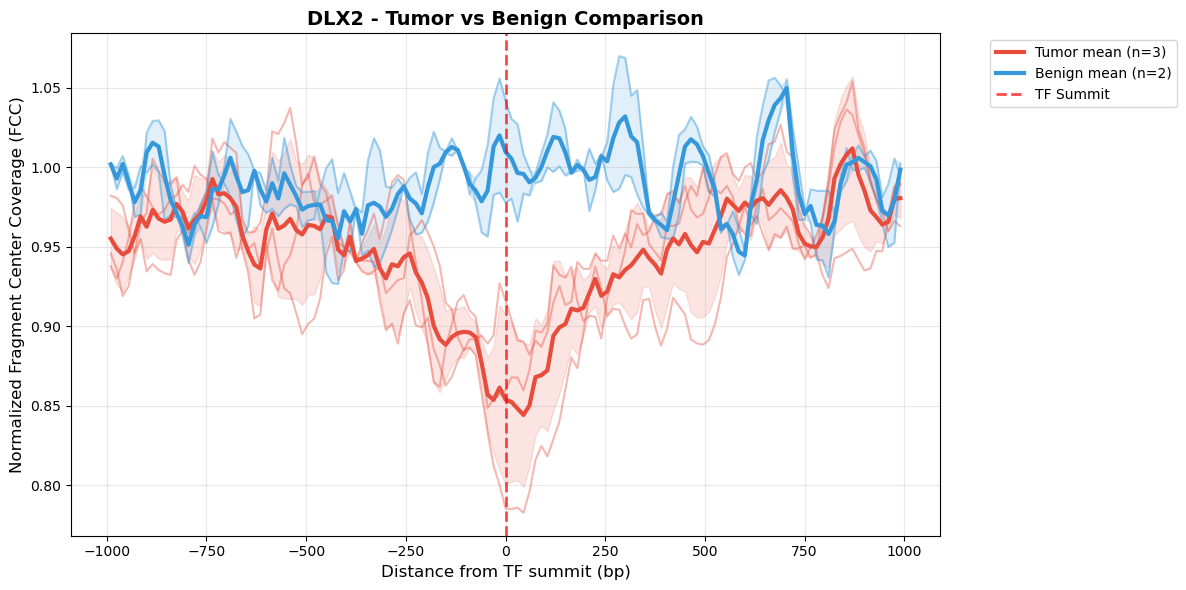

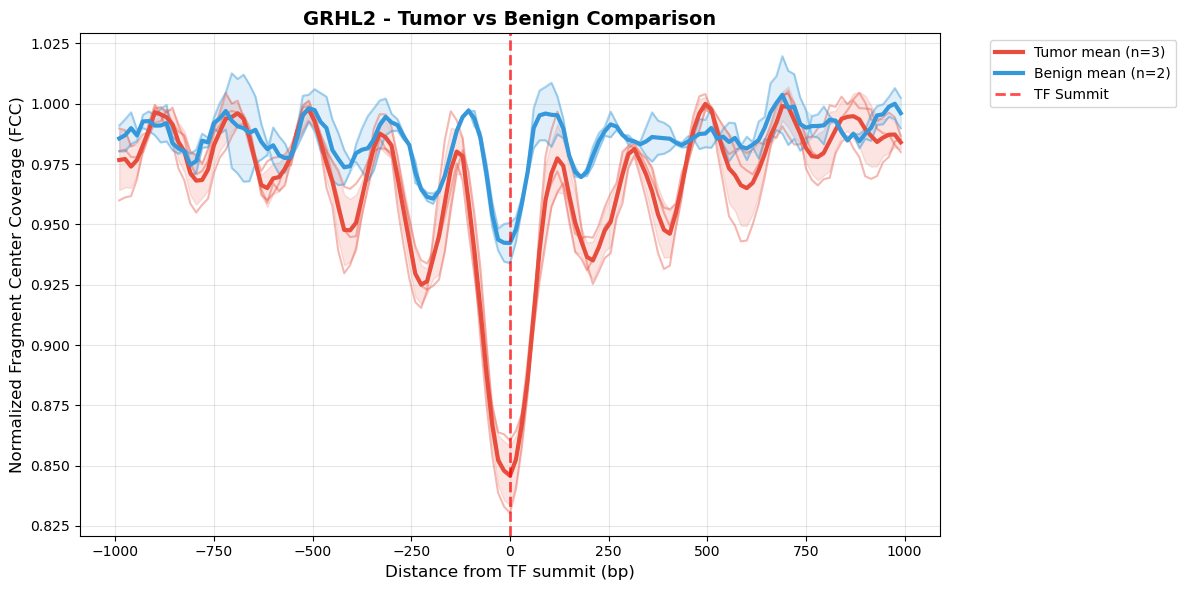

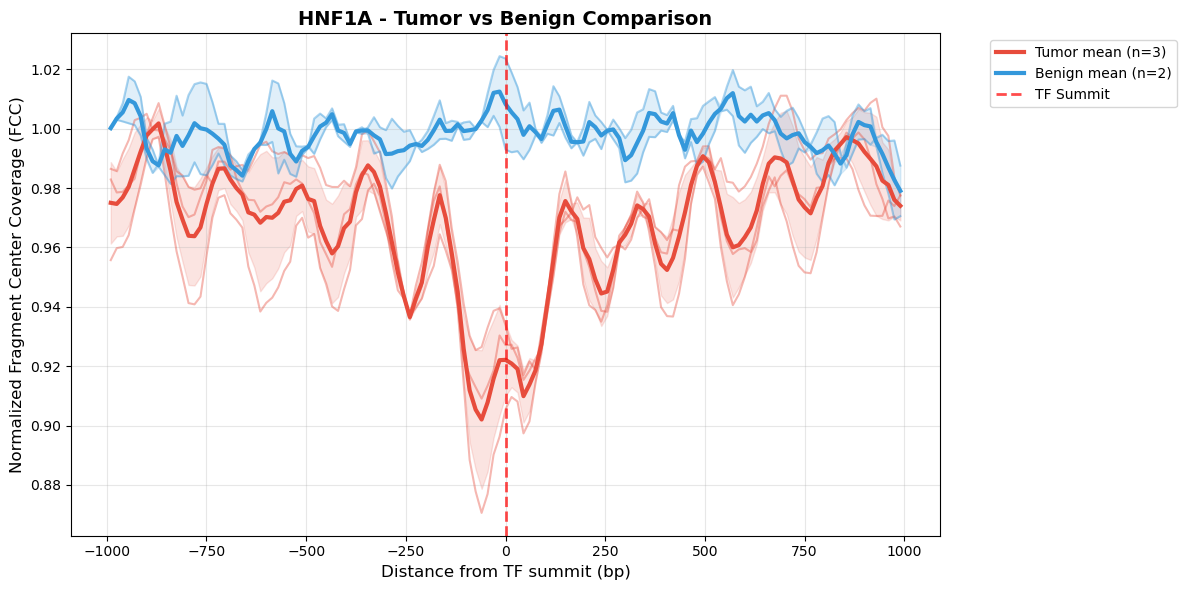

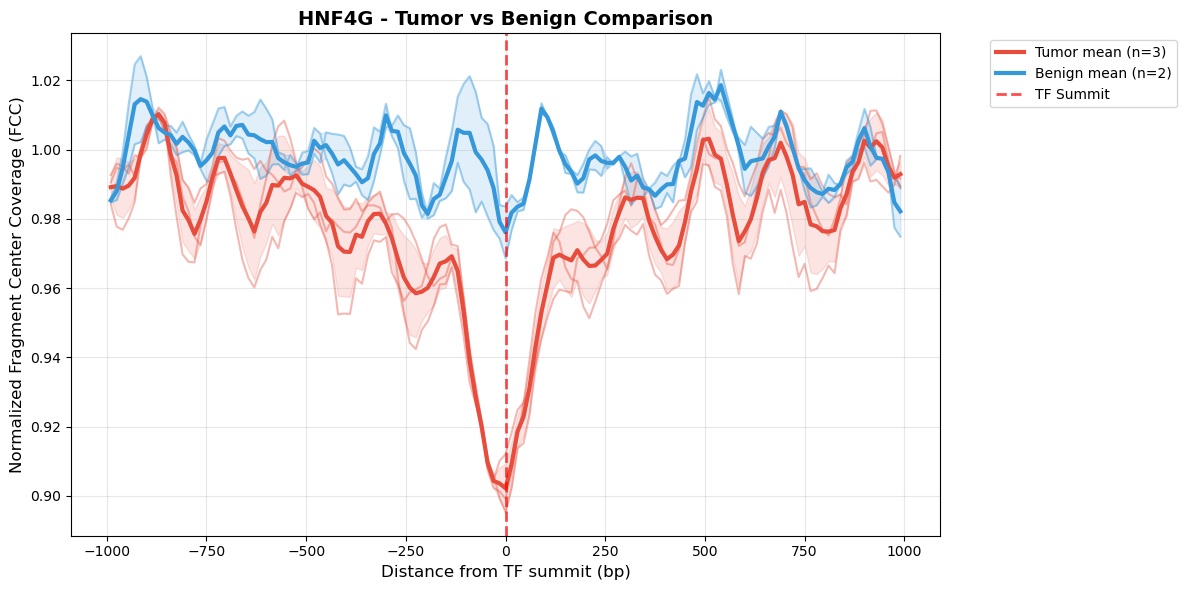

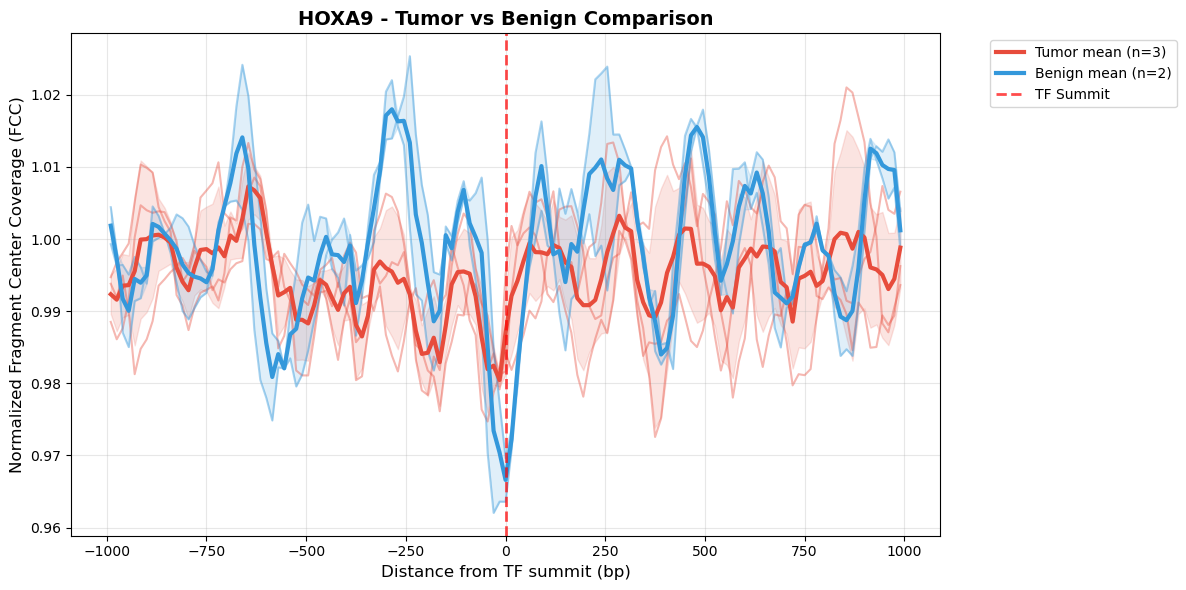

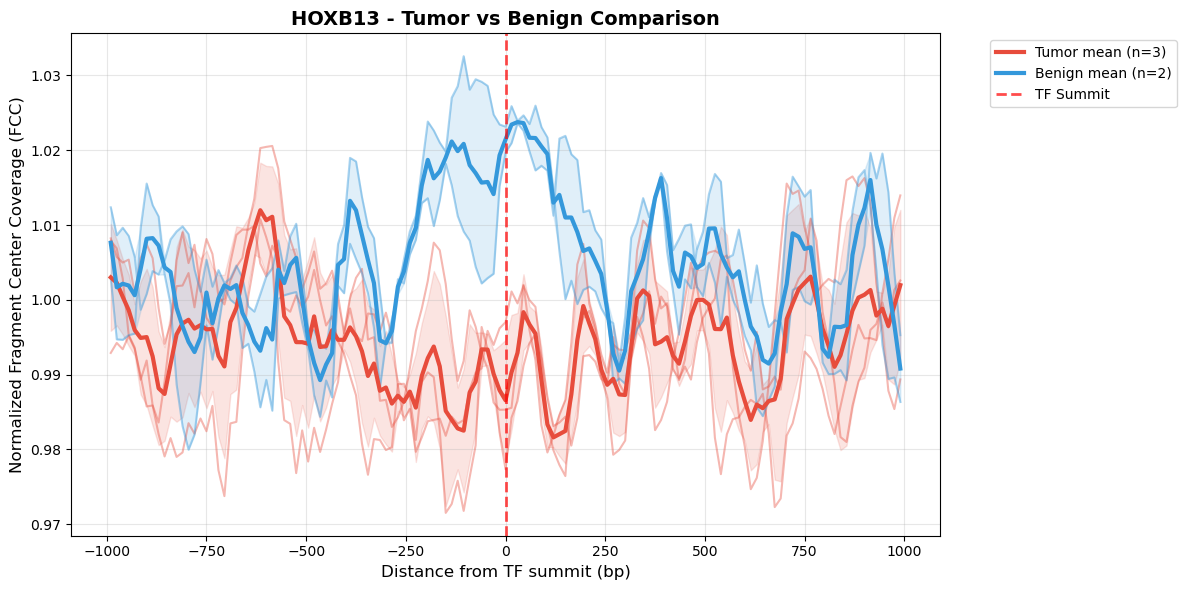

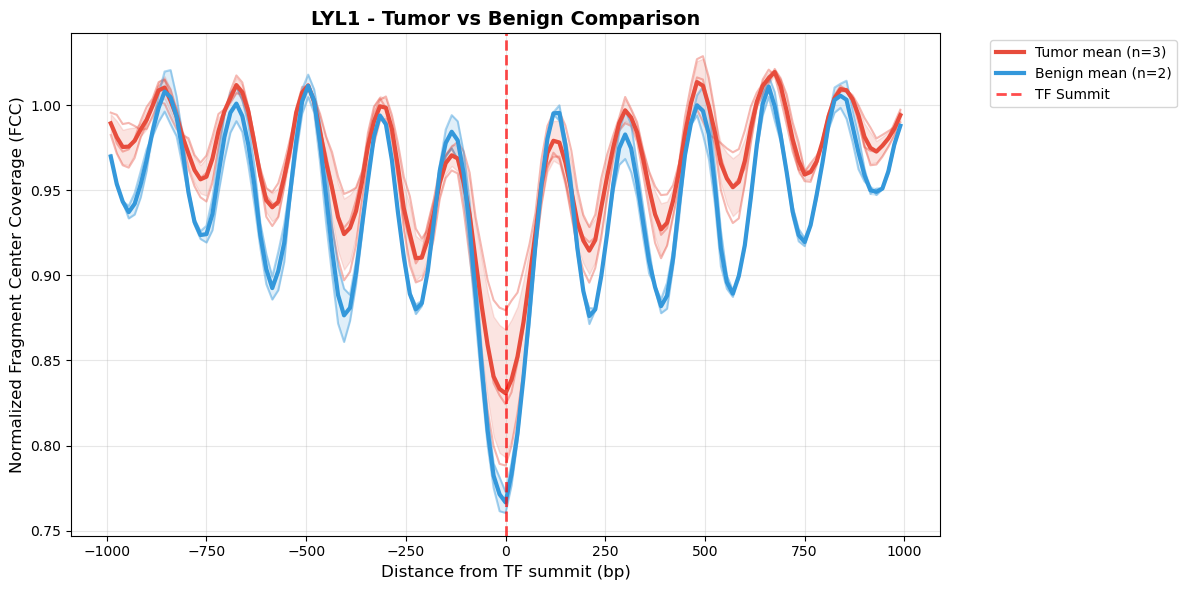

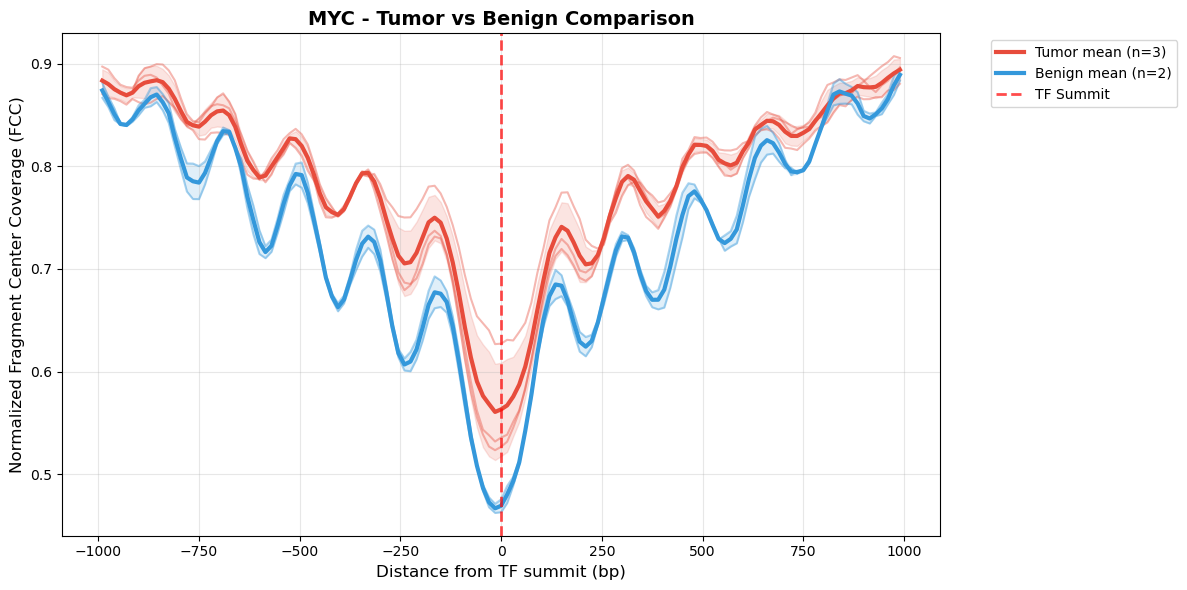

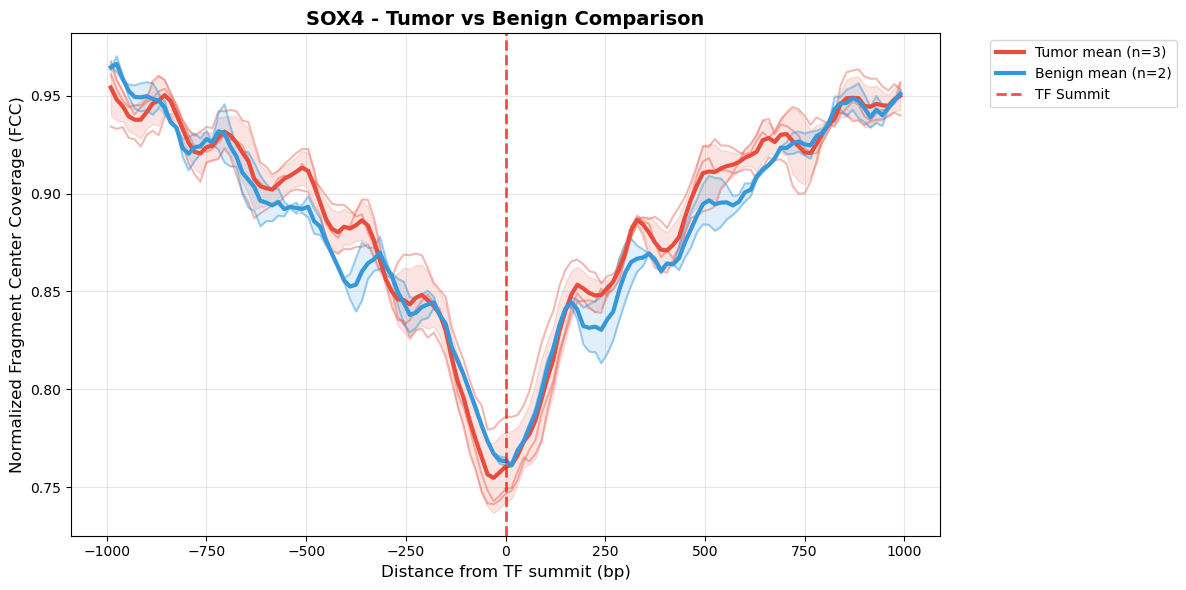

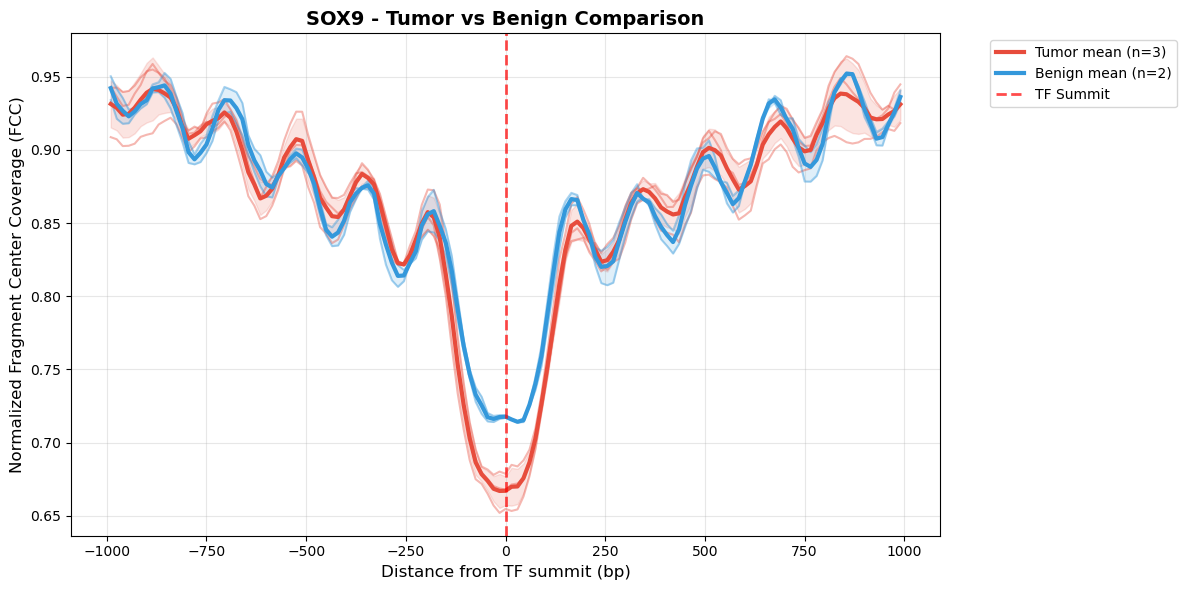

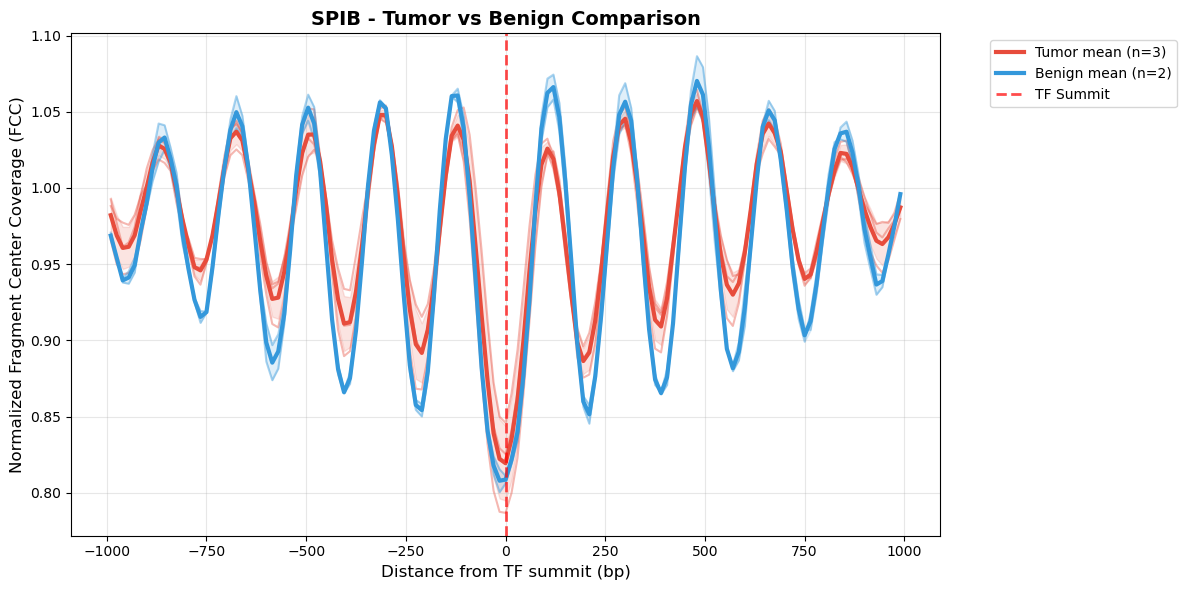

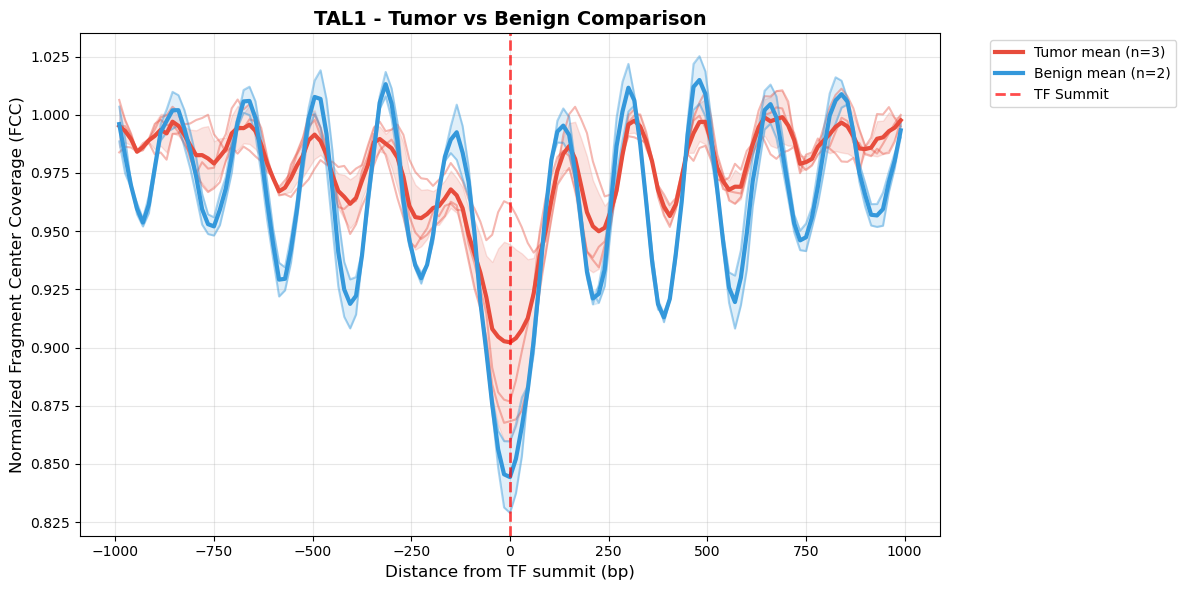

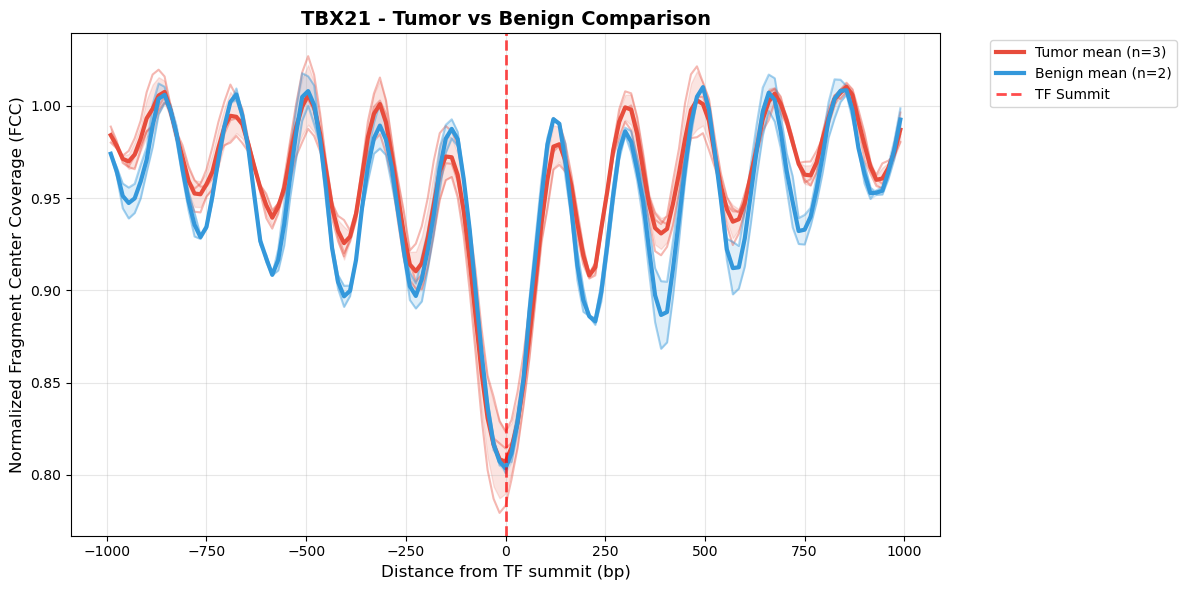

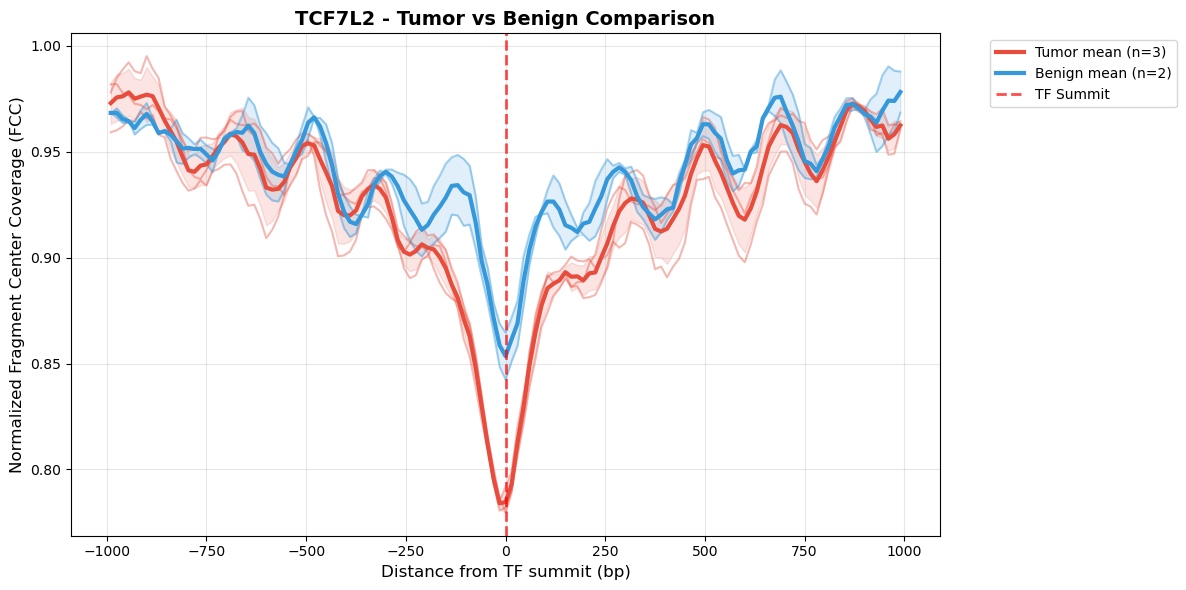

In [6]:
# Define your samples and groups
base_path = "/cluster/work/medinfmk/cfDNA-SeCT/irene_tfp/data/samples"

samples_dict = {
    'samp26_t1': 'SeCT-26_t1',
    'samp26_t2': 'SeCT-26_t2',
    'samp26_t3': 'SeCT-26_t3',
    'samp82': 'SeCT-82',
    'samp58': 'SeCT-58',
}

group_dict = {
    'samp26_t1': 'tumor',
    'samp26_t2': 'tumor',
    'samp26_t3': 'tumor',
    'samp82': 'benign',
    'samp58': 'benign',
}

# List of TFs to analyze
tfs = ['CDX2', 'FOXA1', 'HNF4A', 'GATA6','CTCF','DLX2','GRHL2','HNF1A','HNF4G', 'HOXA9', 'HOXB13', 'LYL1', 'MYC','SOX4','SOX9','SPIB','TAL1','TBX21','TCF7L2']  # Add your TFs here

# Generate all comparison plots for each TF
for tf in tfs:
    print(f"\n{'#'*70}")
    print(f"# Processing {tf}")
    print(f"{'#'*70}\n")
    
    # 1. FCC Profile comparison
    plot_fcc_comparison(tf, samples_dict, group_dict, base_path, show_mean=True)
    


In [4]:
def plot_fcc_comparison(tf_name, samples_dict, group_dict, base_path, 
                        figsize=(15, 3), show_mean=True):
    """
    Plot normalized FCC profiles for all samples on the same plot, colored by group.
    
    Parameters:
    -----------
    tf_name : str
        Name of the transcription factor (e.g., 'CDX2')
    samples_dict : dict
        Dictionary mapping sample names to their sample IDs
    group_dict : dict
        Dictionary mapping sample names to groups ('tumor' or 'benign')
    base_path : str
        Base path to the data directory
    figsize : tuple
        Figure size
    show_mean : bool
        If True, also plot the mean line for each group
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    group_colors = {'tumor': '#588157', 'benign': 'grey'}
    group_data = {'tumor': [], 'benign': []}
    
    # Load and plot all samples
    for sample_name, sample_id in samples_dict.items():
        file_path = f"{base_path}/{sample_id}/griffin_profiling/composite/{tf_name}_profile.tsv.gz"
        df = pd.read_csv(file_path, sep="\t", compression="gzip")
    
        # ✅ keep only positions -1000 to +1000
        df = df[(df['position'] >= -1000) & (df['position'] <= 1000)]
    
        group = group_dict[sample_name]
        
        ax.plot(df['position'], df['normalized_FCC'], 
               color=group_colors[group], 
               alpha=0.4, 
               linewidth=1.5,
               label=f'{sample_name} ({group})' if not show_mean else None)
        
        group_data[group].append(df)
    
    # Plot mean lines for each group
    if show_mean:
        for group, dfs in group_data.items():
            positions = dfs[0]['position']
            mean_fcc = np.mean([df['normalized_FCC'].values for df in dfs], axis=0)
            std_fcc = np.std([df['normalized_FCC'].values for df in dfs], axis=0)
            
            ax.plot(positions, mean_fcc, 
                   color=group_colors[group], 
                   linewidth=3, 
                   label=f'{group.capitalize()} mean (n={len(dfs)})')
            
            ax.fill_between(positions, 
                            mean_fcc - std_fcc, 
                            mean_fcc + std_fcc, 
                            color=group_colors[group], 
                            alpha=0.15)
    
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='TF Summit', alpha=0.7)
    ax.set_xlabel('Distance from TF summit (bp)', fontsize=12)
    ax.set_ylabel('Normalized Coverage', fontsize=12)
    ax.set_title(f'{tf_name} - Tumor vs Healthy Comparison', fontsize=14, fontweight='bold')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{tf_name}.pdf')
    



######################################################################
# Processing PPARG
######################################################################



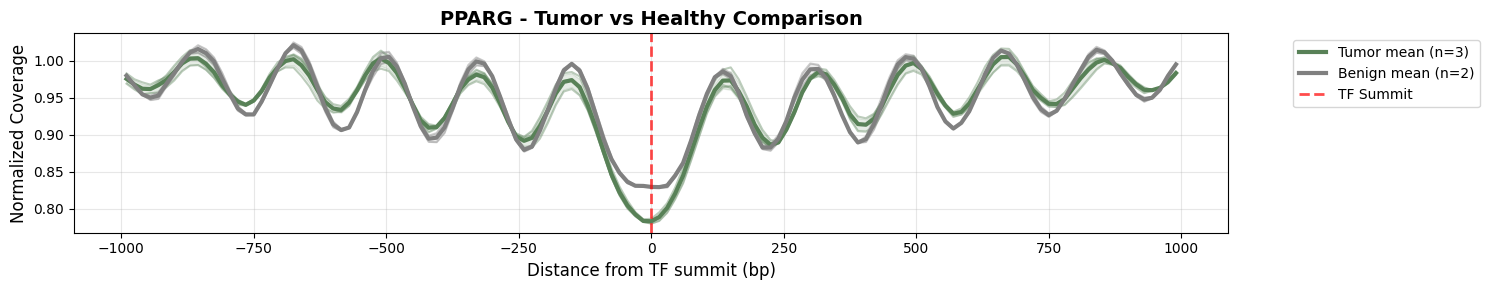

In [12]:
# Define your samples and groups
base_path = "/cluster/work/medinfmk/cfDNA-SeCT/irene_tfp/results/samples"

samples_dict = {
    'samp26_t1': 'SeCT-26_t1',
    'samp26_t2': 'SeCT-26_t2',
    'samp26_t3': 'SeCT-26_t3',
    'samp82': 'SeCT-82',
    'samp58': 'SeCT-58',
}

group_dict = {
    'samp26_t1': 'tumor',
    'samp26_t2': 'tumor',
    'samp26_t3': 'tumor',
    'samp82': 'benign',
    'samp58': 'benign',
}

# List of TFs to analyze
tfs = ['PPARG']  # Add your TFs here

# Generate all comparison plots for each TF
for tf in tfs:
    print(f"\n{'#'*70}")
    print(f"# Processing {tf}")
    print(f"{'#'*70}\n")
    
    # 1. FCC Profile comparison
    plot_fcc_comparison(tf, samples_dict, group_dict, base_path, show_mean=True)
    
    
